# Quantitative Portfolio Research Pipeline

This notebook shows the research code behind the portfolio project. The goal is not to claim a trading strategy. The goal is to show how a quantitative research idea can be turned into a repeatable, testable workflow.

The workflow mirrors quant developer work:

- Load market data into SQL.
- Use Python, pandas, and NumPy to calculate returns and risk.
- Use SciPy to solve constrained portfolio optimization problems.
- Reproduce the minimum-variance optimization in MATLAB for cross-tool validation.
- Run a walk-forward backtest so the model does not use future data.
- Add tests for the calculations and assumptions.
- Generate charts and a report that explain the results.

Historical research only. No live trading or real-money execution is included.

## Research Architecture

```text
Market data
    |
    v
SQL data store
    |
    v
Validation and cleaning
    |
    v
Return and risk engine
    |
    v
Constrained optimizer
    |
    v
Walk-forward backtest
    |
    v
Costs, benchmark comparison, and report
```

The key design choice is separation. Data ingestion, validation, calculations, optimization, backtesting, and reporting are separate pieces so the research can be changed and tested without rewriting the full project.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd

try:
    from scipy.optimize import minimize
except ImportError as exc:
    raise ImportError('Install scipy to run the optimization cells: pip install scipy') from exc

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
@dataclass(frozen=True)
class ResearchConfig:
    tickers: tuple[str, ...] = ('SPY', 'EWC', 'EFA', 'EEM', 'AGG', 'GLD')
    benchmark: str = 'SPY'
    lookback_months: int = 36
    rebalance_frequency: str = 'Q'
    max_asset_weight: float = 0.30
    transaction_cost_bps: float = 10.0
    risk_free_rate: float = 0.03
    trading_days: int = 252
    database_path: str = 'portfolio_research.db'

config = ResearchConfig()
config

ResearchConfig(tickers=('SPY', 'EWC', 'EFA', 'EEM', 'AGG', 'GLD'), benchmark='SPY', lookback_months=36, rebalance_frequency='Q', max_asset_weight=0.3, transaction_cost_bps=10.0, risk_free_rate=0.03, trading_days=252, database_path='portfolio_research.db')

## Market Data

In the portfolio project, the report uses a frozen market snapshot so the results are reproducible. This notebook looks for a local CSV first. If it is not present, it creates a deterministic sample dataset so the notebook can still run during an interview without network access.

A production version would replace the fallback with a scheduled data-freeze step from a licensed market data provider.

In [3]:
def make_demo_prices(config: ResearchConfig, start='2018-01-01', end='2025-12-31') -> pd.DataFrame:
    rng = np.random.default_rng(42)
    dates = pd.bdate_range(start, end)

    annual_returns = {
        'SPY': 0.105,
        'EWC': 0.072,
        'EFA': 0.066,
        'EEM': 0.058,
        'AGG': 0.028,
        'GLD': 0.061,
    }
    annual_vols = {
        'SPY': 0.175,
        'EWC': 0.190,
        'EFA': 0.185,
        'EEM': 0.235,
        'AGG': 0.060,
        'GLD': 0.155,
    }

    # One shared equity factor, one defensive factor, and one commodity factor create realistic correlation patterns.
    factors = rng.normal(size=(len(dates), 3))
    rows = []
    for ticker in config.tickers:
        mu = annual_returns[ticker] / config.trading_days
        sigma = annual_vols[ticker] / np.sqrt(config.trading_days)
        if ticker in {'SPY', 'EWC', 'EFA', 'EEM'}:
            shocks = 0.75 * factors[:, 0] + 0.15 * factors[:, 1] + 0.10 * rng.normal(size=len(dates))
        elif ticker == 'AGG':
            shocks = -0.10 * factors[:, 0] + 0.80 * factors[:, 1] + 0.10 * rng.normal(size=len(dates))
        else:
            shocks = 0.10 * factors[:, 0] + 0.20 * factors[:, 1] + 0.70 * factors[:, 2] + 0.10 * rng.normal(size=len(dates))

        daily_returns = mu + sigma * shocks
        prices = 100 * np.exp(np.cumsum(daily_returns))
        rows.extend({'date': date, 'ticker': ticker, 'adj_close': price} for date, price in zip(dates, prices))

    return pd.DataFrame(rows)

def load_market_data(config: ResearchConfig) -> pd.DataFrame:
    data_path = Path('data/etf_prices.csv')
    if data_path.exists():
        prices = pd.read_csv(data_path, parse_dates=['date'])
    else:
        prices = make_demo_prices(config)

    prices = prices[['date', 'ticker', 'adj_close']].copy()
    prices['date'] = pd.to_datetime(prices['date'])
    prices = prices.sort_values(['ticker', 'date']).reset_index(drop=True)
    return prices

prices = load_market_data(config)
prices.head()

,date,ticker,adj_close
0,2018-01-01,AGG,99.630895
1,2018-01-02,AGG,99.071231
2,2018-01-03,AGG,98.941628
3,2018-01-04,AGG,99.240605
4,2018-01-05,AGG,99.564703


In [4]:
def validate_prices(prices: pd.DataFrame, expected_tickers: tuple[str, ...]) -> pd.DataFrame:
    checks = []
    checks.append(('required_columns', {'date', 'ticker', 'adj_close'}.issubset(prices.columns)))
    checks.append(('no_duplicate_ticker_date', not prices.duplicated(['date', 'ticker']).any()))
    checks.append(('positive_prices', bool((prices['adj_close'] > 0).all())))
    checks.append(('all_expected_tickers_present', set(expected_tickers).issubset(set(prices['ticker']))))
    checks.append(('dates_increasing_by_ticker', prices.groupby('ticker')['date'].apply(lambda s: s.is_monotonic_increasing).all()))

    report = pd.DataFrame(checks, columns=['check', 'passed'])
    if not report['passed'].all():
        failed = report.loc[~report['passed'], 'check'].tolist()
        raise ValueError(f'Data validation failed: {failed}')
    return report

validation_report = validate_prices(prices, config.tickers)
validation_report

,check,passed
0,required_columns,True
1,no_duplicate_ticker_date,True
2,positive_prices,True
3,all_expected_tickers_present,True
4,dates_increasing_by_ticker,True


In [5]:
def load_prices_to_sql(prices: pd.DataFrame, database_path: str) -> sqlite3.Connection:
    con = sqlite3.connect(database_path)
    con.executescript('''
        DROP TABLE IF EXISTS prices;
        CREATE TABLE prices (
            date TEXT NOT NULL,
            ticker TEXT NOT NULL,
            adj_close REAL NOT NULL,
            PRIMARY KEY (date, ticker)
        );
    ''')
    prices.assign(date=prices['date'].dt.strftime('%Y-%m-%d')).to_sql('prices', con, if_exists='append', index=False)
    return con

con = load_prices_to_sql(prices, config.database_path)
pd.read_sql_query('SELECT COUNT(*) AS rows_loaded, COUNT(DISTINCT ticker) AS assets FROM prices', con)

,rows_loaded,assets
0,12528,6


## SQL Examples

These are the kinds of queries the project uses to make the data layer more than a CSV reader. They demonstrate joins, aggregations, common table expressions, and window functions.

In [6]:
daily_return_query = '''
WITH ordered_prices AS (
    SELECT
        date,
        ticker,
        adj_close,
        LAG(adj_close) OVER (PARTITION BY ticker ORDER BY date) AS previous_close
    FROM prices
), daily_returns AS (
    SELECT
        date,
        ticker,
        adj_close / previous_close - 1.0 AS daily_return
    FROM ordered_prices
    WHERE previous_close IS NOT NULL
)
SELECT *
FROM daily_returns
ORDER BY date, ticker;
'''

returns_long = pd.read_sql_query(daily_return_query, con, parse_dates=['date'])
returns_long.head()

,date,ticker,daily_return
0,2018-01-02,AGG,-0.005617
1,2018-01-02,EEM,0.007939
2,2018-01-02,EFA,0.007096
3,2018-01-02,EWC,0.003716
4,2018-01-02,GLD,-0.011755


In [7]:
monthly_volatility_query = '''
WITH daily_returns AS (
    SELECT
        date,
        ticker,
        adj_close / LAG(adj_close) OVER (PARTITION BY ticker ORDER BY date) - 1.0 AS daily_return
    FROM prices
), monthly_stats AS (
    SELECT
        substr(date, 1, 7) AS month,
        ticker,
        AVG(daily_return) AS average_daily_return,
        COUNT(*) AS observations
    FROM daily_returns
    WHERE daily_return IS NOT NULL
    GROUP BY substr(date, 1, 7), ticker
), ranked AS (
    SELECT
        month,
        ticker,
        average_daily_return,
        observations,
        RANK() OVER (PARTITION BY month ORDER BY ABS(average_daily_return) DESC) AS monthly_move_rank
    FROM monthly_stats
)
SELECT *
FROM ranked
WHERE monthly_move_rank <= 3
ORDER BY month, monthly_move_rank;
'''

pd.read_sql_query(monthly_volatility_query, con).head(12)

,month,ticker,average_daily_return,observations,monthly_move_rank
0,2018-01,SPY,0.001406,22,1
1,2018-01,GLD,0.001365,22,2
2,2018-01,EEM,0.001331,22,3
3,2018-02,GLD,-0.001059,20,1
4,2018-02,AGG,-0.000701,20,2
5,2018-02,EEM,-0.000681,20,3
6,2018-03,EEM,0.002169,22,1
7,2018-03,SPY,0.001446,22,2
8,2018-03,EWC,0.001131,22,3
9,2018-04,EEM,-0.003224,21,1


In [8]:
returns = returns_long.pivot(index='date', columns='ticker', values='daily_return').dropna()
returns.head()

ticker,AGG,EEM,EFA,EWC,GLD,SPY
date,,,,,,
2018-01-02,-0.005617,0.007939,0.007096,0.003716,-0.011755,0.003709
2018-01-03,-0.001308,0.003036,-0.001184,-0.000041,-0.000621,0.001424
2018-01-04,0.003022,-0.006774,-0.007132,-0.008613,0.006950,-0.003927
2018-01-05,0.003266,0.006021,0.001889,0.000288,0.006081,0.002743
2018-01-08,0.001439,-0.008319,-0.005695,-0.004603,-0.005709,-0.006282


## Financial Calculations

These functions convert raw returns into the financial inputs needed for the optimizer and report.

In [9]:
def annualized_return(daily_returns: pd.Series, trading_days: int = 252) -> float:
    compounded = (1 + daily_returns).prod()
    years = len(daily_returns) / trading_days
    return compounded ** (1 / years) - 1

def annualized_volatility(daily_returns: pd.Series, trading_days: int = 252) -> float:
    return daily_returns.std(ddof=1) * np.sqrt(trading_days)

def sharpe_ratio(daily_returns: pd.Series, risk_free_rate: float, trading_days: int = 252) -> float:
    excess_return = annualized_return(daily_returns, trading_days) - risk_free_rate
    vol = annualized_volatility(daily_returns, trading_days)
    return excess_return / vol

def drawdown(daily_returns: pd.Series) -> pd.Series:
    wealth = (1 + daily_returns).cumprod()
    running_peak = wealth.cummax()
    return wealth / running_peak - 1

def value_at_risk(daily_returns: pd.Series, confidence: float = 0.95) -> float:
    return -np.quantile(daily_returns, 1 - confidence)

def portfolio_returns(returns: pd.DataFrame, weights: np.ndarray) -> pd.Series:
    return pd.Series(returns.to_numpy() @ weights, index=returns.index)

asset_summary = pd.DataFrame({
    'annual_return': returns.apply(annualized_return),
    'annual_volatility': returns.apply(annualized_volatility),
    'daily_var_95': returns.apply(value_at_risk),
})
asset_summary

,annual_return,annual_volatility,daily_var_95
ticker,,,
AGG,0.015759,0.049364,0.005100
EEM,0.102031,0.178668,0.018259
EFA,0.088668,0.140685,0.014190
EWC,0.092408,0.145111,0.014556
GLD,0.027424,0.117475,0.011973
SPY,0.136535,0.132546,0.013124


In [10]:
def portfolio_metrics(daily_returns: pd.Series, config: ResearchConfig) -> dict[str, float]:
    return {
        'annual_return': annualized_return(daily_returns, config.trading_days),
        'annual_volatility': annualized_volatility(daily_returns, config.trading_days),
        'sharpe_ratio': sharpe_ratio(daily_returns, config.risk_free_rate, config.trading_days),
        'maximum_drawdown': drawdown(daily_returns).min(),
        'daily_var_95': value_at_risk(daily_returns),
    }

covariance = returns.cov() * config.trading_days
correlation = returns.corr()
correlation

ticker,AGG,EEM,EFA,EWC,GLD,SPY
ticker,,,,,,
AGG,1.000000,0.095415,0.093975,0.094013,0.278163,0.095223
EEM,0.095415,1.000000,0.982585,0.982016,0.164117,0.983040
EFA,0.093975,0.982585,1.000000,0.983307,0.163223,0.983809
EWC,0.094013,0.982016,0.983307,1.000000,0.163311,0.982480
GLD,0.278163,0.164117,0.163223,0.163311,1.000000,0.159976
SPY,0.095223,0.983040,0.983809,0.982480,0.159976,1.000000


## Optimization

The optimizer solves two common portfolio problems:

1. Minimum variance: find the lowest-risk mix.
2. Maximum Sharpe: find the best return per unit of risk.

Both are constrained: weights must add to 100%, no short positions are allowed, and no asset can be more than 30% of the portfolio.

In [11]:
def optimize_portfolio(returns_window: pd.DataFrame, config: ResearchConfig, objective: str = 'max_sharpe') -> pd.Series:
    assets = list(returns_window.columns)
    n_assets = len(assets)
    mean_returns = returns_window.mean().to_numpy() * config.trading_days
    covariance = returns_window.cov().to_numpy() * config.trading_days

    bounds = [(0.0, config.max_asset_weight) for _ in range(n_assets)]
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    initial = np.repeat(1.0 / n_assets, n_assets)

    def variance(weights: np.ndarray) -> float:
        return float(weights.T @ covariance @ weights)

    def negative_sharpe(weights: np.ndarray) -> float:
        port_return = float(weights @ mean_returns)
        port_volatility = np.sqrt(variance(weights))
        return -(port_return - config.risk_free_rate) / port_volatility

    objective_function = variance if objective == 'min_variance' else negative_sharpe
    result = minimize(objective_function, initial, method='SLSQP', bounds=bounds, constraints=constraints)
    if not result.success:
        raise RuntimeError(result.message)

    return pd.Series(result.x, index=assets).clip(lower=0)

latest_window = returns.iloc[-config.trading_days * 3:]
weights_min_var = optimize_portfolio(latest_window, config, objective='min_variance')
weights_max_sharpe = optimize_portfolio(latest_window, config, objective='max_sharpe')

pd.DataFrame({'minimum_variance': weights_min_var, 'maximum_sharpe': weights_max_sharpe})

,minimum_variance,maximum_sharpe
AGG,3.000000e-01,0.005168
EEM,1.743972e-17,0.300000
EFA,1.082184e-01,0.000000
EWC,0.000000e+00,0.094832
GLD,3.000000e-01,0.300000
SPY,2.917816e-01,0.300000


## MATLAB Comparison

This is the same minimum-variance idea written in MATLAB style. The point is to show willingness to support quantitative models across the tools used by the team.

```matlab
% Minimum-variance portfolio with long-only weights and a 30% asset cap
Sigma = cov(returns) * 252;
n = size(Sigma, 1);

f = zeros(n, 1);
Aeq = ones(1, n);
beq = 1;
lb = zeros(n, 1);
ub = 0.30 * ones(n, 1);

options = optimoptions('quadprog', 'Display', 'off');
weights = quadprog(2 * Sigma, f, [], [], Aeq, beq, lb, ub, [], options);
```

In the full project, the Python and MATLAB minimum-variance weights are compared within a tolerance so a model change can be reviewed instead of silently accepted.

## Walk-Forward Backtest

This is the most important part of the research design. The model estimates weights using only past data, then tests those weights on the next period. That prevents look-ahead bias.

In [12]:
def walk_forward_backtest(returns: pd.DataFrame, config: ResearchConfig, objective: str = 'max_sharpe') -> tuple[pd.Series, pd.DataFrame]:
    lookback_days = int(config.lookback_months * config.trading_days / 12)
    rebalance_dates = returns.resample(config.rebalance_frequency).last().index
    rebalance_dates = [date for date in rebalance_dates if date in returns.index and returns.index.get_loc(date) >= lookback_days]

    portfolio_daily_returns = []
    weight_records = []
    previous_weights = pd.Series(0.0, index=returns.columns)
    cost_rate = config.transaction_cost_bps / 10_000

    for i, rebalance_date in enumerate(rebalance_dates[:-1]):
        next_rebalance_date = rebalance_dates[i + 1]
        end_position = returns.index.get_loc(rebalance_date)
        train = returns.iloc[end_position - lookback_days:end_position + 1]
        test = returns.loc[(returns.index > rebalance_date) & (returns.index <= next_rebalance_date)]

        weights = optimize_portfolio(train, config, objective=objective)
        turnover = (weights - previous_weights).abs().sum()
        transaction_cost = turnover * cost_rate

        period_returns = portfolio_returns(test, weights.to_numpy())
        if not period_returns.empty:
            period_returns.iloc[0] -= transaction_cost
            portfolio_daily_returns.append(period_returns)

        weight_records.append({
            'rebalance_date': rebalance_date,
            'next_rebalance_date': next_rebalance_date,
            'turnover': turnover,
            'transaction_cost': transaction_cost,
            **weights.to_dict(),
        })
        previous_weights = weights

    return pd.concat(portfolio_daily_returns).sort_index(), pd.DataFrame(weight_records)

strategy_returns, rebalance_history = walk_forward_backtest(returns, config)
benchmark_returns = returns.loc[strategy_returns.index, config.benchmark]

pd.DataFrame({
    'optimized_portfolio': portfolio_metrics(strategy_returns, config),
    'benchmark': portfolio_metrics(benchmark_returns, config),
})

/var/folders/bk/w06ly1yn09bgl47y13n5zpf00000gn/T/ipykernel_10877/2090468429.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  rebalance_dates = returns.resample(config.rebalance_frequency).last().index


,optimized_portfolio,benchmark
annual_return,0.137317,0.212379
annual_volatility,0.110734,0.130285
sharpe_ratio,0.969149,1.399848
maximum_drawdown,-0.088619,-0.105223
daily_var_95,0.010812,0.012710


In [13]:
rebalance_history.tail()

,rebalance_date,next_rebalance_date,turnover,transaction_cost,AGG,EEM,EFA,EWC,GLD,SPY
10,2024-09-30,2024-12-31,1.200000e+00,1.200000e-03,1.892070e-18,0.1,3.000000e-01,0.3,2.815601e-17,0.3
11,2024-12-31,2025-03-31,4.000000e-01,4.000000e-04,9.385261e-17,0.3,1.000000e-01,0.3,0.000000e+00,0.3
12,2025-03-31,2025-06-30,4.902974e-16,4.902974e-19,3.376668e-17,0.3,1.000000e-01,0.3,0.000000e+00,0.3
13,2025-06-30,2025-09-30,7.311761e-17,7.311761e-20,3.003800e-17,0.3,1.000000e-01,0.3,0.000000e+00,0.3
14,2025-09-30,2025-12-31,2.000000e-01,2.000000e-04,0.000000e+00,0.3,3.469447e-17,0.3,1.000000e-01,0.3


## MATLAB Visualization Equivalents

The rendered charts below are produced from the same research data in the notebook. Since the role specifically mentions MATLAB, this section shows how the visual review can be reproduced in MATLAB once the return series, benchmark series, correlation matrix, and optimized weights are exported from the Python pipeline.

```matlab
% Growth of $1
portfolioGrowth = cumprod(1 + strategyReturns);
benchmarkGrowth = cumprod(1 + benchmarkReturns);
plot(dates, portfolioGrowth, LineWidth, 2); hold on;
plot(dates, benchmarkGrowth, LineWidth, 2);
title(Growth of $1);
ylabel(Portfolio value);
legend(Optimized portfolio, Benchmark);

% Drawdown
portfolioDrawdown = portfolioGrowth ./ cummax(portfolioGrowth) - 1;
benchmarkDrawdown = benchmarkGrowth ./ cummax(benchmarkGrowth) - 1;
figure;
plot(dates, portfolioDrawdown, LineWidth, 2); hold on;
plot(dates, benchmarkDrawdown, LineWidth, 2);
title(Drawdown);
ylabel(Drawdown);
legend(Optimized portfolio, Benchmark);

% Correlation heatmap
figure;
heatmap(assetNames, assetNames, correlationMatrix);
title(Daily Return Correlation);

% Latest optimized weights
figure;
barh(latestWeights);
yticklabels(assetNames);
xlabel(Portfolio weight);
title(Latest Optimized Weights);
```

This helps show that the research is not locked to one plotting library. Python handles the pipeline and MATLAB can reproduce the model checks and charting workflow used by a quant team.


## Visual Checks

These outputs make the research easier to review. The charts show whether the optimized portfolio grows differently from the benchmark, how painful the worst declines were, how the assets move together, and whether the latest allocation is concentrated.

For the interview, this is the visualization story: the same calculations feed both the Python report and the MATLAB-style review section above. That shows the model can be inspected across tools, not just hidden behind one charting package.


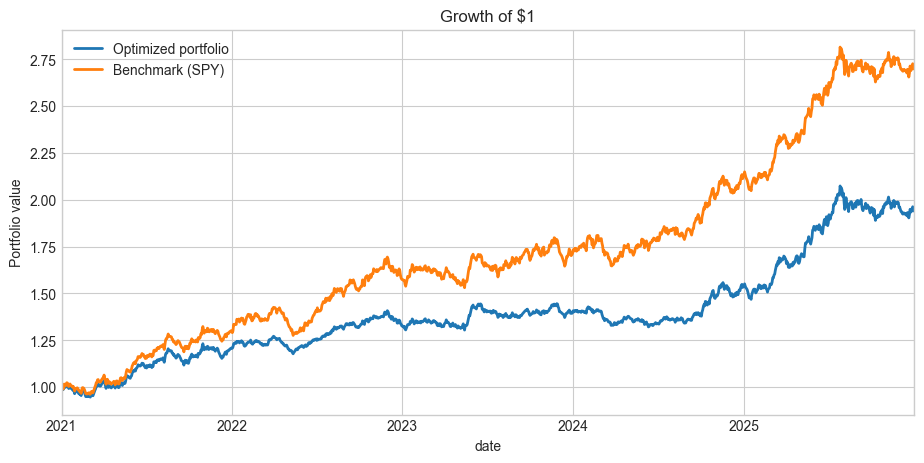

In [14]:
growth = pd.DataFrame({
    'Optimized portfolio': (1 + strategy_returns).cumprod(),
    f'Benchmark ({config.benchmark})': (1 + benchmark_returns).cumprod(),
})

ax = growth.plot(figsize=(11, 5), linewidth=2)
ax.set_title('Growth of $1')
ax.set_ylabel('Portfolio value')
plt.show()

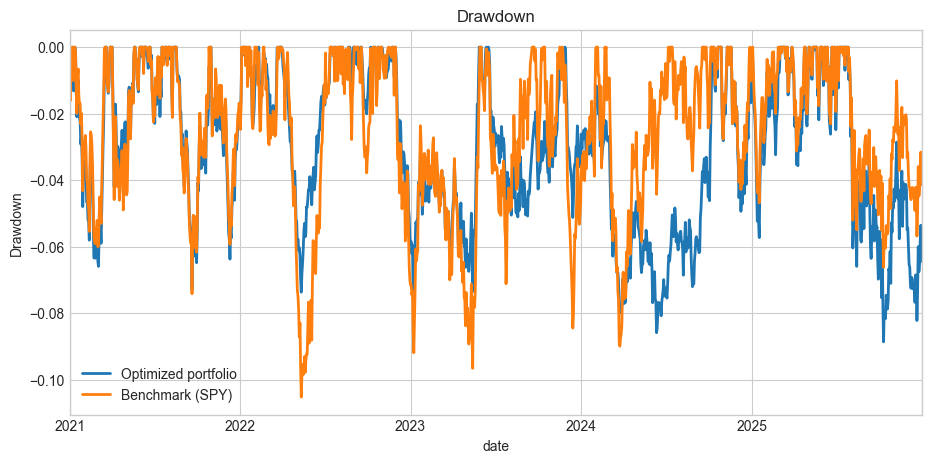

In [15]:
dd = pd.DataFrame({
    'Optimized portfolio': drawdown(strategy_returns),
    f'Benchmark ({config.benchmark})': drawdown(benchmark_returns),
})

ax = dd.plot(figsize=(11, 5), linewidth=2)
ax.set_title('Drawdown')
ax.set_ylabel('Drawdown')
plt.show()

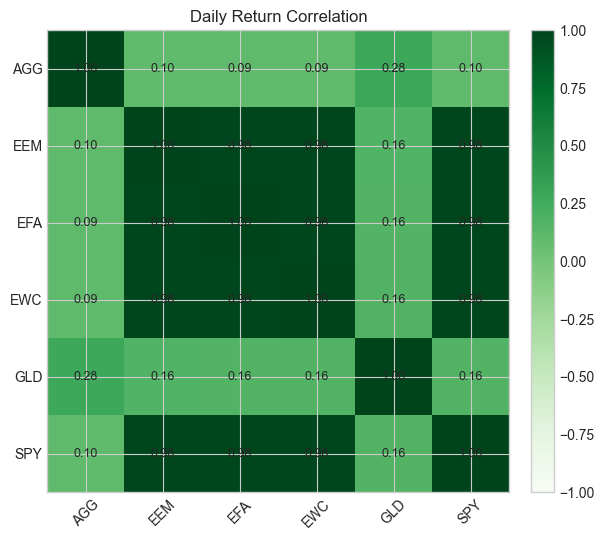

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(correlation, cmap='Greens', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
ax.set_yticks(range(len(correlation.index)), correlation.index)
for i in range(len(correlation.index)):
    for j in range(len(correlation.columns)):
        ax.text(j, i, f'{correlation.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Daily Return Correlation')
plt.show()

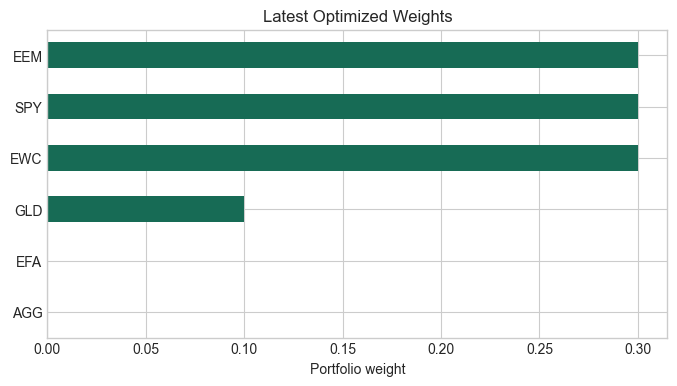

In [17]:
latest_weights = rebalance_history.set_index('rebalance_date')[list(config.tickers)].iloc[-1].sort_values(ascending=True)
ax = latest_weights.plot(kind='barh', figsize=(8, 4), color='#176b55')
ax.set_title('Latest Optimized Weights')
ax.set_xlabel('Portfolio weight')
plt.show()

## How To Read The Visuals

- Growth of $1 shows whether the optimized strategy added value versus the benchmark over time.
- Drawdown shows the worst loss from a previous high, which is often more intuitive than volatility alone.
- Correlation shows diversification quality. Lower correlation means the assets are less likely to fall together.
- Optimized weights show the final portfolio recommendation under the 30% maximum asset constraint.

A quant developer is not only expected to calculate these metrics. They also need to make the results reviewable by researchers, portfolio managers, and risk teams.


## Calculation Tests

These are small examples of the tests that matter in a quant project. The goal is to make sure the simple financial building blocks are correct before trusting the larger optimization and backtest.

In [18]:
def test_daily_return_math():
    simple_prices = pd.Series([100, 110])
    calculated = simple_prices.pct_change().iloc[1]
    assert np.isclose(calculated, 0.10)

def test_portfolio_return_math():
    simple_returns = pd.DataFrame({'Asset A': [0.10], 'Asset B': [0.00]})
    weights = np.array([0.50, 0.50])
    calculated = portfolio_returns(simple_returns, weights).iloc[0]
    assert np.isclose(calculated, 0.05)

def test_optimizer_constraints():
    weights = optimize_portfolio(latest_window, config, objective='max_sharpe')
    assert np.isclose(weights.sum(), 1.0, atol=1e-6)
    assert (weights >= -1e-8).all()
    assert (weights <= config.max_asset_weight + 1e-6).all()

def test_walk_forward_chronology():
    assert (rebalance_history['next_rebalance_date'] > rebalance_history['rebalance_date']).all()

for test in [
    test_daily_return_math,
    test_portfolio_return_math,
    test_optimizer_constraints,
    test_walk_forward_chronology,
]:
    test()

'All notebook checks passed'

'All notebook checks passed'

## What The Project Demonstrates

This project demonstrates the practical parts of quant development:

- Translating an investment question into calculations and code.
- Using SQL as a structured data layer, not just relying on spreadsheets.
- Using Python and pandas for financial analytics.
- Using optimization under realistic constraints.
- Avoiding look-ahead bias with walk-forward testing.
- Accounting for transaction costs and turnover.
- Reproducing a model in MATLAB for validation.
- Writing tests around financial calculations and model assumptions.

The result is a small research pipeline that could be explained, rerun, reviewed, and modified by a quantitative research team.